# Proyecto: DaisyWorld Espacio-Temporal 🌼🌎

Este notebook implementa una primera versión del modelo espacial de Daisyworld. El objetivo es evolucionar de un sistema de Ecuaciones Diferenciales Ordinarias (EDO) a un sistema de Ecuaciones en Derivadas Parciales (EDP), simulando un dominio cuadrado con condiciones de borde periódicas (bucles espacio-temporales para simular un planeta esférico).

Se calcularán y graficarán tanto la evolución temporal de los valores medios globales como la distribución espacial 2D en el estado final. Además de una animación donde se aprecie cómo las flores compiten por territorio.

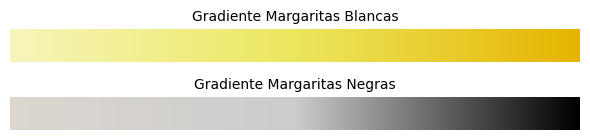

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random

from matplotlib.colors import LinearSegmentedColormap

# Configuración para que los gráficos se vean bien en el notebook
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 5)

# Gradientes customizados para las flores
colors_w = ["#f7f5bc", "#ece75f", "#e6b400"]
flores_blancas = LinearSegmentedColormap.from_list("marg_blancas", colors_w)

colors_b = ["#dcd7d0", "#cccccc", "#000000"]
flores_negras = LinearSegmentedColormap.from_list("marg_negras", colors_b)

# Visualización de los gradientes
gradient = np.linspace(0, 1, 256).reshape(1, -1)
fig, axes = plt.subplots(2, 1, figsize=(6, 1.5))

axes[0].imshow(gradient, aspect='auto', cmap=flores_blancas)
axes[0].set_title('Gradiente Margaritas Blancas', fontsize=10)
axes[0].axis('off')

axes[1].imshow(gradient, aspect='auto', cmap=flores_negras)
axes[1].set_title('Gradiente Margaritas Negras', fontsize=10)
axes[1].axis('off')

plt.tight_layout()
plt.show()

## 1. Definición de Parámetros y Dominio
A continuación, definimos las constantes físicas y biológicas del modelo, así como la discretización del espacio y el tiempo.

In [2]:
# Parámetros equilibrados para Daisyworld espacial
N = 100
L = 500.0
dx = L / N
dt = 0.05
pasos = 4000      # Reducido de 10000 a 4000 para capturar hasta t=200

# Constantes Físicas: S=3000 mantiene el planeta habitable
K = 0.05
S = 3000.0
sigma = 5.67e-08
C = 10.0
A_w = 0.75
A_b = 0.25
A_s = 0.50

# Constantes Biológicas
D_w = 1.0
D_b = 1.0
gamma = 0.03
T_opt = 22.5

## 2. Operador Laplaciano Periódico
Para la difusión, utilizamos diferencias finitas centradas. La condición de borde periódica (topología toroidal) se implementa de manera eficiente utilizando la función `np.roll` de NumPy, la cual "envuelve" los bordes de la matriz.

El operador aproxima: $$\nabla^2 U \approx \frac{\partial^2 U}{\partial x^2} + \frac{\partial^2 U}{\partial y^2}$$

In [3]:
def laplacian_2d(U, dx):
    """
    Calcula el Laplaciano 2D usando diferencias finitas con condiciones
    de borde periódicas.
    """
    lap_x = (np.roll(U, -1, axis=0) - 2.0 * U + np.roll(U, 1, axis=0)) / (dx**2)
    lap_y = (np.roll(U, -1, axis=1) - 2.0 * U + np.roll(U, 1, axis=1)) / (dx**2)
    return lap_x + lap_y

def tasa_crecimiento(T):
    """
    Se modela como una parábola invertida centrada en T_opt.
    El crecimiento es máximo cuando T = T_opt y disminuye cuando
    la temperatura se aleja de ese valor.

    La función se trunca en cero para evitar tasas negativas.
    """
    beta = 1.0 - 0.003265 * (T - T_opt)**2
    # Evitar tasas negativas usando np.maximum
    return np.maximum(0.0, beta)

## 3. Condiciones Iniciales
Inicializamos el planeta con una temperatura uniforme y densidades bajas de margaritas. Para fomentar la dinámica espacial, introducimos una pequeña perturbación aleatoria en las poblaciones iniciales.

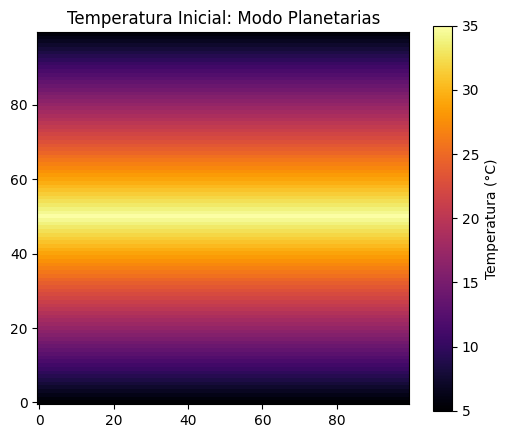

In [4]:
# @title 🌍 Configuración de Condiciones Iniciales de Temperatura
modo_inicial = "planetarias" # @param ["homogenea", "ruido", "planetarias", "parches"]

# Inicialización base
T = np.ones((N, N)) * 20.0

if modo_inicial == "ruido":
    # Ruido blanco entre 15 y 25 grados
    T += (np.random.rand(N, N) - 0.5) * 10.0

elif modo_inicial == "planetarias":
    # Gradiente desde el ecuador (centro) a los polos (bordes superior/inferior)
    for i in range(N):
        latitud = np.abs(i - N/2) / (N/2)
        T[i, :] = 35.0 - (latitud * 30.0) # 35°C en ecuador, 5°C en polos

elif modo_inicial == "parches":
    # Crear parches de calor y frío aleatorios
    temp_patches = np.zeros((N, N))
    for _ in range(10):
        size = random.randint(5, 15)
        x, y = random.randint(0, N-size), random.randint(0, N-size)
        valor = random.uniform(-10, 10)
        temp_patches[x:x+size, y:y+size] = valor
    T += temp_patches

# Visualizar la condición elegida
plt.figure(figsize=(6, 5))
plt.imshow(T, cmap='inferno', origin='lower')
plt.title(f'Temperatura Inicial: Modo {modo_inicial.capitalize()}')
plt.colorbar(label='Temperatura (°C)')
plt.show()

In [5]:
import random

def generate_random_patches(alpha_matrix, num_patches, max_patch_size_ratio=0.1, density=0.5):
    """Función para generar parches biológicos aleatorios."""
    for _ in range(num_patches):
        patch_size = random.randint(1, int(N * max_patch_size_ratio))
        x_start = random.randint(0, N - patch_size)
        y_start = random.randint(0, N - patch_size)
        alpha_matrix[x_start:x_start + patch_size, y_start:y_start + patch_size] = density

# Reiniciar margaritas para la nueva simulación
alpha_w = np.zeros((N, N))
alpha_b = np.zeros((N, N))

# Aplicar la lógica de parches biológicos
generate_random_patches(alpha_w, 5, max_patch_size_ratio=0.08, density=0.3)
generate_random_patches(alpha_b, 5, max_patch_size_ratio=0.08, density=0.3)

print(f"Condiciones iniciales listas en modo: {modo_inicial}")

Condiciones iniciales listas en modo: planetarias


In [6]:
import random

# NOTA: Eliminamos el reinicio de T aquí para no perder la configuración del widget superior
# Si T no existe (primera corrida), la inicializamos
if 'T' not in globals():
    T = np.ones((N, N)) * 20.0

# Empezamos con el planeta vacío (0 margaritas)
alpha_w = np.zeros((N, N))
alpha_b = np.zeros((N, N))

# Función para generar un parche aleatorio
def generate_random_patches(alpha_matrix, num_patches, max_patch_size_ratio=0.1, density=0.5):
    for _ in range(num_patches):
        patch_size = random.randint(1, int(N * max_patch_size_ratio))
        x_start = random.randint(0, N - patch_size)
        y_start = random.randint(0, N - patch_size)
        x_end = x_start + patch_size
        y_end = y_start + patch_size
        alpha_matrix[x_start:x_end, y_start:y_end] = density

# Generar parches aleatorios para margaritas
num_patches_w = random.randint(2, 5)
generate_random_patches(alpha_w, num_patches_w, max_patch_size_ratio=0.05, density=0.5)

num_patches_b = random.randint(2, 5)
generate_random_patches(alpha_b, num_patches_b, max_patch_size_ratio=0.05, density=0.5)

# Listas para almacenar los valores medios
tiempos = []
T_mean = []
alpha_w_mean = []
alpha_b_mean = []

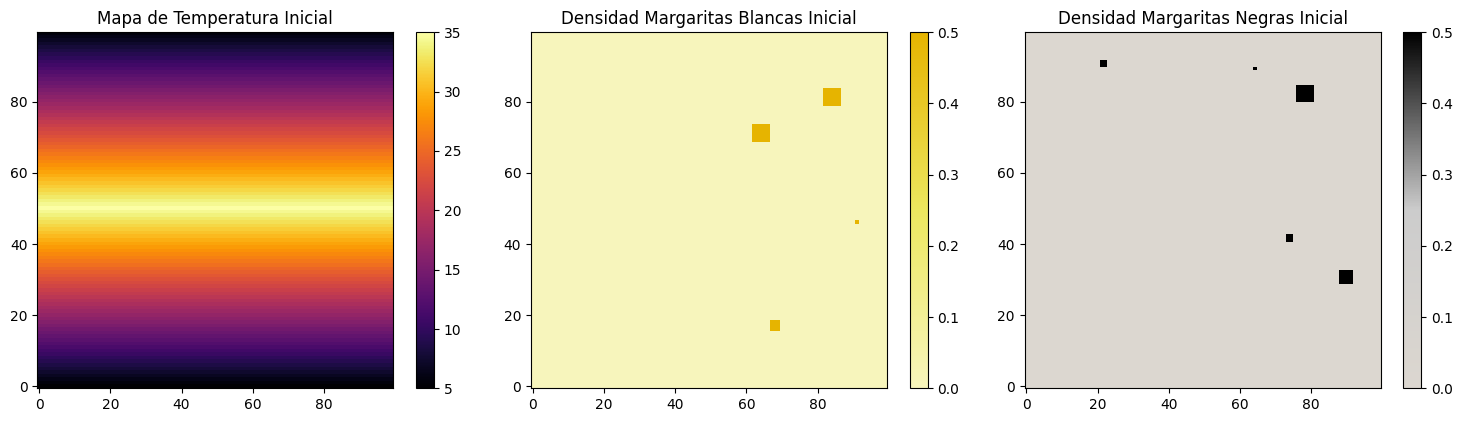

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Mapa de Temperatura Inicial
im1 = axes[0].imshow(T, cmap='inferno', origin='lower')
axes[0].set_title('Mapa de Temperatura Inicial')
fig.colorbar(im1, ax=axes[0])

# Mapa Margaritas Blancas Inicial
im2 = axes[1].imshow(alpha_w, cmap=flores_blancas, origin='lower', vmin=0, vmax=np.max(alpha_w) if np.max(alpha_w) > 0 else 1.0)
axes[1].set_title('Densidad Margaritas Blancas Inicial')
fig.colorbar(im2, ax=axes[1])

# Mapa Margaritas Negras Inicial
im3 = axes[2].imshow(alpha_b, cmap=flores_negras, origin='lower', vmin=0, vmax=np.max(alpha_b) if np.max(alpha_b) > 0 else 1.0)
axes[2].set_title('Densidad Margaritas Negras Inicial')
fig.colorbar(im3, ax=axes[2])

plt.tight_layout()
plt.show()

## 4. Bucle Principal de Simulación
Resolvemos el sistema acoplado de ecuaciones de reacción-difusión utilizando el método de Euler hacia adelante. En cada iteración, se calcula el albedo local, se aplican los operadores de difusión y se actualiza el estado del sistema. También registramos los promedios globales.

In [8]:
from tqdm.auto import tqdm

# NOTA: Eliminamos los reinicios de T, alpha_w y alpha_b
# para mantener las condiciones iniciales configuradas arriba.

historial_T, historial_w, historial_b = [], [], []
tiempos, T_mean, alpha_w_mean, alpha_b_mean = [], [], [], []

# Reducimos este valor para capturar más fotogramas y suavizar la animación
pasos_por_fotograma = 50

# Bucle de simulación
for step in tqdm(range(pasos), desc="Simulando Daisyworld"):
    # 1. Albedo promedio local
    A_p = alpha_w * A_w + alpha_b * A_b + (1.0 - alpha_w - alpha_b) * A_s

    # 2. Crecimiento biológico
    espacio_libre = np.clip(1.0 - alpha_w - alpha_b, 0.0, 1.0)
    beta_loc = tasa_crecimiento(T)

    # 3. Operadores espaciales
    lap_T = laplacian_2d(T, dx)
    lap_w = laplacian_2d(alpha_w, dx)
    lap_b = laplacian_2d(alpha_b, dx)

    # 4. Ecuaciones de evolución
    T_kelvin = T + 273.15
    dT_dt = (K * lap_T + ((S / 4.0) * (1.0 - A_p) - sigma * (T_kelvin**4))) / C
    dw_dt = alpha_w * (beta_loc * espacio_libre - gamma) + D_w * lap_w
    db_dt = alpha_b * (beta_loc * espacio_libre - gamma) + D_b * lap_b

    # 5. Actualización
    T += dt * dT_dt
    alpha_w += dt * dw_dt
    alpha_b += dt * db_dt

    # Limitadores físicos
    alpha_w = np.clip(alpha_w, 0.0, 1.0)
    alpha_b = np.clip(alpha_b, 0.0, 1.0)

    if step % pasos_por_fotograma == 0:
        tiempos.append(step * dt)
        T_mean.append(np.mean(T))
        alpha_w_mean.append(np.mean(alpha_w))
        alpha_b_mean.append(np.mean(alpha_b))
        historial_T.append(T.copy())
        historial_w.append(alpha_w.copy())
        historial_b.append(alpha_b.copy())

print(f"Simulación finalizada. T_final promedio: {np.mean(T):.2f}°C")

Simulando Daisyworld:   0%|          | 0/4000 [00:00<?, ?it/s]

Simulación finalizada. T_final promedio: 23.21°C


## 5. Resultados y Visualización (Valores medios y distribución espacial final)
Generamos los gráficos para visualizar:
1. **Gráfico 1D:** Evolución temporal de los valores medios globales (Temperatura y Poblaciones).
2. **Gráfico 2D:** Mapas de calor (Heatmaps) mostrando la distribución espacial final.

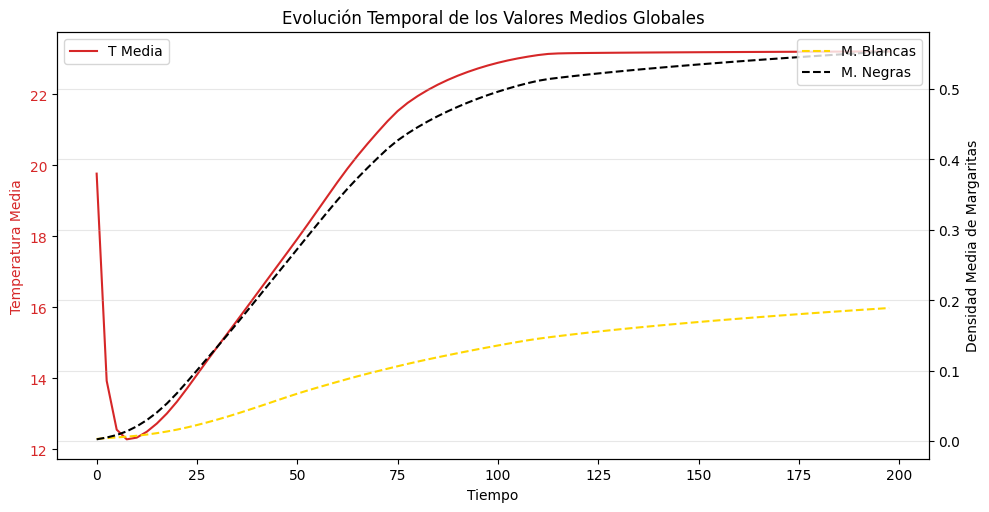

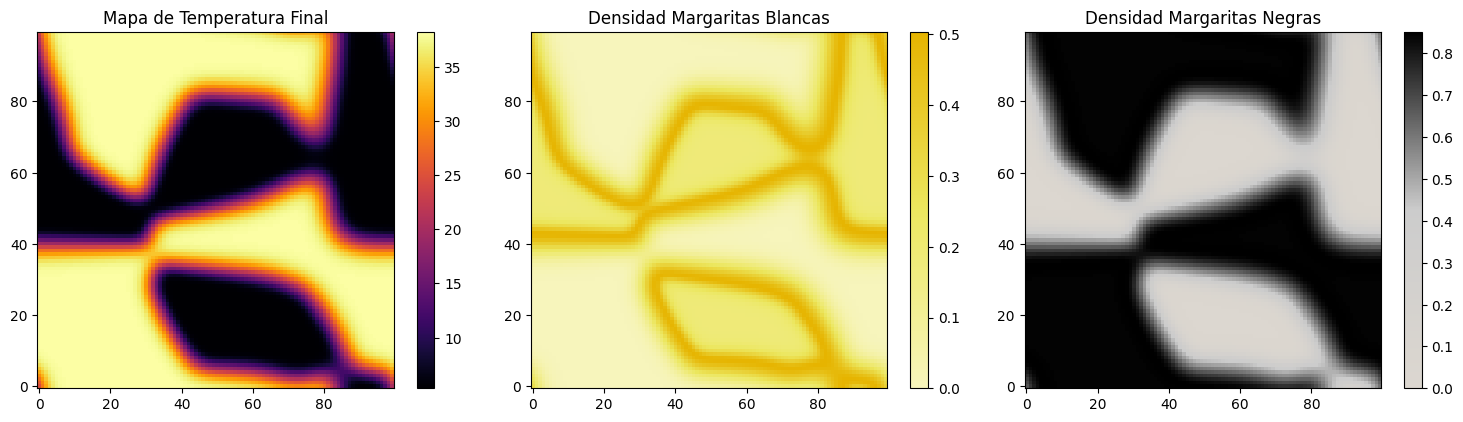

In [9]:
# Gráfico de Evolución Temporal (Valores Medios)
fig, ax1 = plt.subplots(figsize=(10, 5))

color = 'tab:red'
ax1.set_xlabel('Tiempo')
ax1.set_ylabel('Temperatura Media', color=color)
ax1.plot(tiempos, T_mean, color=color, label='T Media')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color_w = 'gold'
color_b = 'black'
ax2.set_ylabel('Densidad Media de Margaritas')
ax2.plot(tiempos, alpha_w_mean, color=color_w, label='M. Blancas', linestyle='--')
ax2.plot(tiempos, alpha_b_mean, color=color_b, label='M. Negras', linestyle='--')
ax2.tick_params(axis='y')

fig.tight_layout()
plt.title('Evolución Temporal de los Valores Medios Globales')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.show()

# Gráficos Espaciales 2D (Estado Final)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Mapa de Temperatura
im1 = axes[0].imshow(T, cmap='inferno', origin='lower')
axes[0].set_title('Mapa de Temperatura Final')
fig.colorbar(im1, ax=axes[0])

# Mapa Margaritas Blancas
im2 = axes[1].imshow(alpha_w, cmap=flores_blancas, origin='lower', vmin=0)
axes[1].set_title('Densidad Margaritas Blancas')
fig.colorbar(im2, ax=axes[1])

# Mapa Margaritas Negras
im3 = axes[2].imshow(alpha_b, cmap=flores_negras, origin='lower', vmin=0)
axes[2].set_title('Densidad Margaritas Negras')
fig.colorbar(im3, ax=axes[2])

plt.tight_layout()
plt.show()

## 6. Animación (Espacio-Temporal)
Generamos un video (animación) para apreciar la evolución de la población de margaritas.

In [ ]:
import matplotlib.animation as animation
from IPython.display import HTML
from tqdm.auto import tqdm

# Configurar la figura para la animación
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Inicializar las imágenes
im_T = axes[0].imshow(historial_T[0], cmap='inferno', origin='lower', vmin=np.min(historial_T), vmax=np.max(historial_T))
im_w = axes[1].imshow(historial_w[0], cmap=flores_blancas, origin='lower', vmin=0, vmax=1.0)
im_b = axes[2].imshow(historial_b[0], cmap=flores_negras, origin='lower', vmin=0, vmax=1.0)

# Títulos
axes[0].set_title('Temperatura')
axes[1].set_title('Margaritas Blancas')
axes[2].set_title('Margaritas Negras')

# Añadir barras de color
fig.colorbar(im_T, ax=axes[0], fraction=0.046, pad=0.04)
fig.colorbar(im_w, ax=axes[1], fraction=0.046, pad=0.04)
fig.colorbar(im_b, ax=axes[2], fraction=0.046, pad=0.04)

plt.tight_layout()

# Barra de progreso
pbar = tqdm(total=len(historial_T), desc="Generando Animación")

def update(frame):
    im_T.set_array(historial_T[frame])
    im_w.set_array(historial_w[frame])
    im_b.set_array(historial_b[frame])
    fig.suptitle(f"Tiempo: {frame * dt * pasos_por_fotograma:.1f}", fontsize=16)
    pbar.update(1)
    return [im_T, im_w, im_b]

# Ajustamos interval a 40 para una reproducción más rápida y fluida
ani = animation.FuncAnimation(fig, update, frames=len(historial_T), interval=40, blit=False)

# Renderizar la animación
anim_html = ani.to_jshtml()
pbar.close()

plt.close()

# Mostrar el reproductor interactivo
HTML(anim_html)

Generando Animación:   0%|          | 0/80 [00:00<?, ?it/s]

In [ ]:
# @title 💾 Guardar esta simulación como MP4
# Ejecuta esta celda solo si te gusta el video de arriba y quieres descargarlo.

print("Generando archivo MP4...")
writer = animation.FFMpegWriter(fps=15, metadata=dict(artist='DaisyWorld'), bitrate=1800)
ani.save('daisyworld_sim.mp4', writer=writer)
print("¡Listo! El archivo 'daisyworld_sim.mp4' ya está disponible en el explorador de archivos.")

Generando archivo MP4...
¡Listo! El archivo 'daisyworld_sim.mp4' ya está disponible en el explorador de archivos.
